# Backpropagation Using PyTorch

In this notebook, We will learn:

- what backpropagation is
- how a neural network makes predictions
- how loss is calculated
- how gradients are computed
- how weights are updated using PyTorch


## 1. What is Backpropagation?

Backpropagation is the process used to train a neural network.

It works in 5 simple steps:

1. Take input data
2. Do a forward pass to get prediction
3. Calculate the loss (error)
4. Compute gradients using backward pass
5. Update weights to reduce the error

The goal is to make predictions better after every epoch.

## 2. Intuition

A neural network starts with random weights.

Because the weights are random, the predictions are usually wrong at first.

Backpropagation tells us:
- which weight caused how much error
- how each weight should change

PyTorch can calculate these gradients automatically using `loss.backward()`.

### Imports

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

## 3. Create a Small Dataset

In [2]:
X = torch.tensor([
    [2.0, 3.0],
    [5.0, 6.0],
    [7.0, 8.0]
])

y = torch.tensor([
    [3.0],
    [4.0],
    [5.0]
])

print("X shape:", X.shape)
print("y shape:", y.shape)


print("Input data:")
print(X)

print("\nTarget data:")
print(y)

X shape: torch.Size([3, 2])
y shape: torch.Size([3, 1])
Input data:
tensor([[2., 3.],
        [5., 6.],
        [7., 8.]])

Target data:
tensor([[3.],
        [4.],
        [5.]])


## 4. Neural Network Structure

We will build a very small network:

- input layer = 2 neurons
- hidden layer = 2 neurons
- output layer = 1 neuron

So the flow is:

$$
Input \rightarrow Hidden \rightarrow Output
$$

PyTorch will manage the weights for us.

### Build The Model In Simple Way

In [3]:
model = nn.Sequential(
    nn.Linear(2, 2),
    nn.Linear(2, 1)
)

model

Sequential(
  (0): Linear(in_features=2, out_features=2, bias=True)
  (1): Linear(in_features=2, out_features=1, bias=True)
)

## 5. Initial Weights and Biases

In [4]:
for name, param in model.named_parameters():
    print(name)
    print(param)
    print()

0.weight
Parameter containing:
tensor([[-0.3031, -0.0281],
        [-0.4393, -0.1181]], requires_grad=True)

0.bias
Parameter containing:
tensor([0.6960, 0.6973], requires_grad=True)

1.weight
Parameter containing:
tensor([[-0.1249,  0.3253]], requires_grad=True)

1.bias
Parameter containing:
tensor([0.0202], requires_grad=True)



## 6. Forward Pass

In the forward pass, input goes through the network and gives an output prediction.

PyTorch does this when we write:

```python

y_pred = model(X)
print("Predictions before training:")
print(y_pred)

```

## 7. Loss Function

Loss tells us how wrong the prediction is.

We will use Mean Squared Error (MSE):

$$
Loss = \frac{1}{n}\sum(y - \hat{y})^2
$$

Smaller loss means better predictions.

In [6]:
y_pred = model(X)
print("Predictions before training:")
print(y_pred)

Predictions before training:
tensor([[-0.1548],
        [-0.5746],
        [-0.8545]], grad_fn=<AddmmBackward0>)


In [7]:
loss_fn = nn.MSELoss()
loss = loss_fn(y_pred, y)

print("Initial loss:", loss.item())

Initial loss: 21.718626022338867


## 8. Backward Pass

Now we calculate gradients.

This is where backpropagation happens.

In PyTorch, this is just:

```python
loss.backward()

### Show gradients

In [8]:
for name, param in model.named_parameters():
    print(f"Gradient of {name}:")
    print(param.grad)
    print()

Gradient of 0.weight:
None

Gradient of 0.bias:
None

Gradient of 1.weight:
None

Gradient of 1.bias:
None



## 9. Updating Weights

After gradients are computed, we update the weights.

We use an optimizer for that.

A simple optimizer is SGD (Stochastic Gradient Descent).

In [9]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

## 10. One Full Training Step

The correct training order is:

1. forward pass
2. calculate loss
3. clear old gradients
4. backward pass
5. update weights

In [10]:
# forward pass
y_pred = model(X)

# loss
loss = loss_fn(y_pred, y)
print("Loss before update:", loss.item())

# clear old gradients
optimizer.zero_grad()

# backward pass
loss.backward()

# update weights
optimizer.step()

Loss before update: 21.718626022338867


### Show Updated Parameters

In [11]:
for name, param in model.named_parameters():
    print(name)
    print(param)
    print()

0.weight
Parameter containing:
tensor([[-0.3615, -0.0978],
        [-0.2872,  0.0635]], requires_grad=True)

0.bias
Parameter containing:
tensor([0.6847, 0.7267], requires_grad=True)

1.weight
Parameter containing:
tensor([[-0.2194,  0.1169]], requires_grad=True)

1.bias
Parameter containing:
tensor([0.1107], requires_grad=True)



## 11. Training for Many Epochs

In [12]:
model = nn.Sequential(
    nn.Linear(2, 2),
    nn.Linear(2, 1)
)

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

epochs = 100
loss_history = []

for epoch in range(epochs):
    # forward
    y_pred = model(X)

    # loss
    loss = loss_fn(y_pred, y)

    # clear previous gradients
    optimizer.zero_grad()

    # backward
    loss.backward()

    # update
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss = {loss.item():.4f}")

Epoch 10, Loss = 0.3435
Epoch 20, Loss = 0.3037
Epoch 30, Loss = 0.2673
Epoch 40, Loss = 0.2341
Epoch 50, Loss = 0.2039
Epoch 60, Loss = 0.1767
Epoch 70, Loss = 0.1524
Epoch 80, Loss = 0.1307
Epoch 90, Loss = 0.1116
Epoch 100, Loss = 0.0949


## 12. Loss Curve

This plot helps us see whether the model is learning.

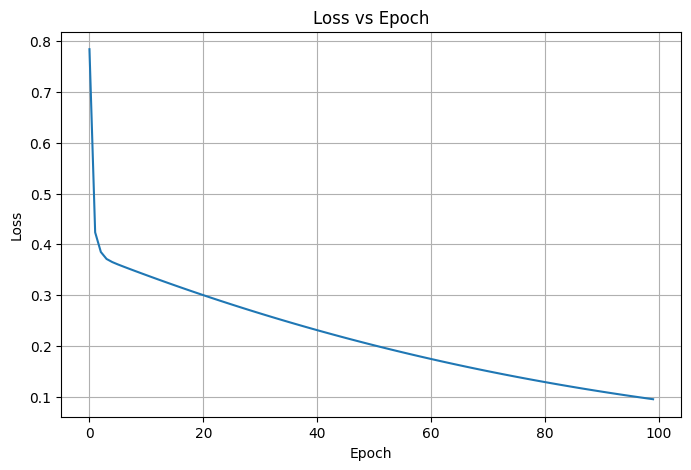

In [13]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.grid(True)
plt.show()

## 13. Predictions After Training

In [14]:
with torch.no_grad():
    final_pred = model(X)

print("Actual values:")
print(y)

print("\nPredicted values after training:")
print(final_pred)

Actual values:
tensor([[3.],
        [4.],
        [5.]])

Predicted values after training:
tensor([[2.4933],
        [4.0766],
        [5.1322]])


## 14. Why use `torch.no_grad()`?

During prediction, we do not need gradients. This makes prediction faster and saves memory.

So we use:

```python
with torch.no_grad():

## 15. Note About Activation Functions

In this simple notebook, we did not use an activation function.

In real neural networks, we often use activations like:

- ReLU
- Sigmoid
- Tanh

For learning backpropagation, this basic version is enough.

In [15]:
model_relu = nn.Sequential(
    nn.Linear(2, 2),
    nn.ReLU(),
    nn.Linear(2, 1)
)

model_relu

Sequential(
  (0): Linear(in_features=2, out_features=2, bias=True)
  (1): ReLU()
  (2): Linear(in_features=2, out_features=1, bias=True)
)

In [16]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model_relu.parameters(), lr=0.01)

loss_history_relu = []

for epoch in range(100):
    y_pred = model_relu(X)
    loss = loss_fn(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history_relu.append(loss.item())

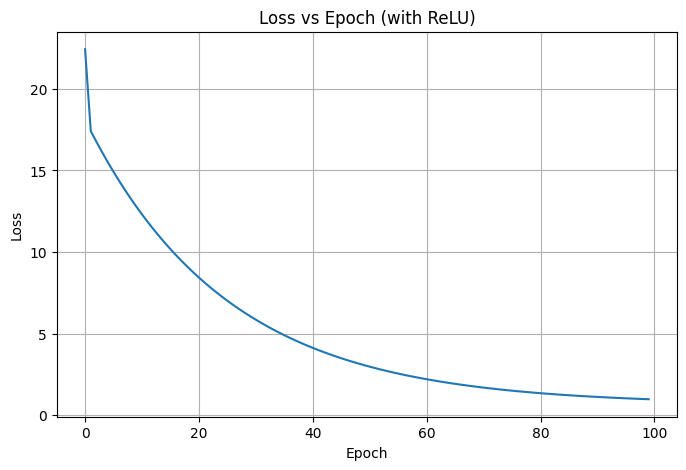

In [17]:
plt.figure(figsize=(8,5))
plt.plot(loss_history_relu)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch (with ReLU)")
plt.grid(True)
plt.show()

## 16. Summary

In this notebook, We learned:

- a neural network makes predictions using a forward pass
- loss measures how wrong the prediction is
- backpropagation computes gradients
- `loss.backward()` calculates gradients automatically in PyTorch
- `optimizer.step()` updates the weights
- repeating this process over many epochs reduces the loss